In [ ]:
import pandas as pd

In [2]:
df = pd.read_csv('data/raw/train.csv')

In [3]:
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


/tmp/ipykernel_308224/4196663861.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


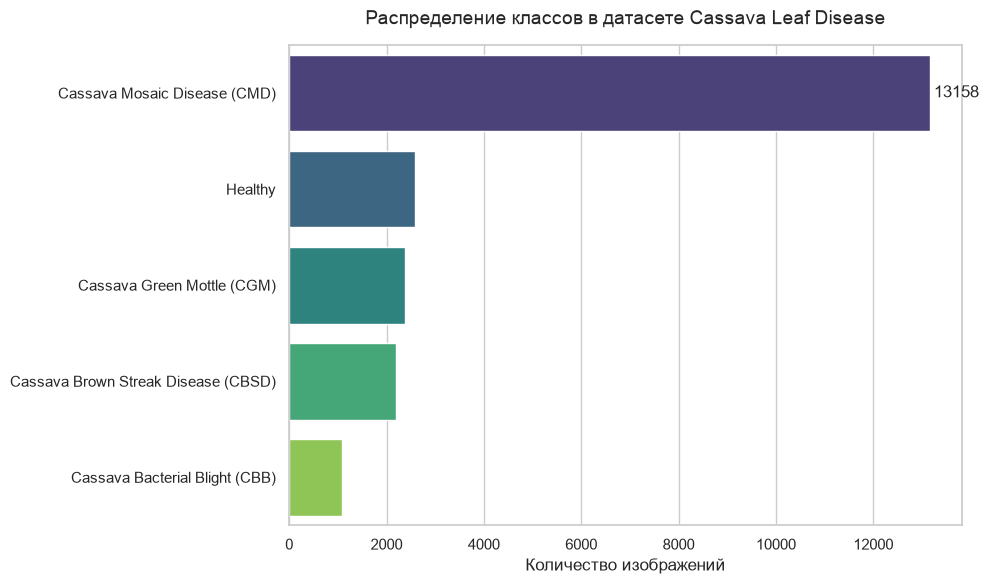

Процентное соотношение классов:
label
3    61.49%
4    12.04%
2    11.15%
1    10.23%
0     5.08%
Name: proportion, dtype: object


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import json

with open('data/raw/label_num_to_disease_map.json', 'r') as f:
    disease_map = json.load(f)

df['disease_name'] = df['label'].astype(str).map(disease_map)

# Настраиваем стиль
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Строим barplot
ax = sns.countplot(
    data=df, 
    y='disease_name', 
    order=df['disease_name'].value_counts().index, 
    palette='viridis'
)

ax.bar_label(ax.containers[0], padding=3)

plt.title('Распределение классов в датасете Cassava Leaf Disease', fontsize=14, pad=15)
plt.xlabel('Количество изображений', fontsize=12)
plt.ylabel('', fontsize=12)
plt.tight_layout()
plt.show()

print("Процентное соотношение классов:")
print((df['label'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')